In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import roc_auc_score, f1_score, classification_report, accuracy_score, average_precision_score, PrecisionRecallDisplay, confusion_matrix
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


In [20]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

DATA_DIR = r"C:\Users\Siq\Desktop\Gerald Challange\data"

def load_all_datasets(data_dir):
    
    datasets = {}
    
    # 1. Customers
    datasets['customers'] = pd.read_csv(f"{data_dir}/olist_customers_dataset.csv")
    
    # 2. Geolocation
    datasets['geolocation'] = pd.read_csv(f"{data_dir}/olist_geolocation_dataset.csv")
    
    # 3. Order Items
    datasets['items'] = pd.read_csv(
        f"{data_dir}/olist_order_items_dataset.csv",
        parse_dates=['shipping_limit_date']
    )
    
    # 4. Order Payments
    datasets['payments'] = pd.read_csv(f"{data_dir}/olist_order_payments_dataset.csv")
    
    # 5. Order Reviews
    datasets['reviews'] = pd.read_csv(
        f"{data_dir}/olist_order_reviews_dataset.csv",
        parse_dates=['review_creation_date', 'review_answer_timestamp']
    )
    
    # 6. Orders
    datasets['orders'] = pd.read_csv(
        f"{data_dir}/olist_orders_dataset.csv",
        parse_dates=[
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    )
    
    # 7. Products
    datasets['products'] = pd.read_csv(f"{data_dir}/olist_products_dataset.csv")
    
    # 8. Sellers
    datasets['sellers'] = pd.read_csv(f"{data_dir}/olist_sellers_dataset.csv")
    
    # 9. Category translation
    datasets['translation'] = pd.read_csv(
        f"{data_dir}/product_category_name_translation.csv"
    )
    return datasets

# Run the loader and store everything in a dictionary
data = load_all_datasets(DATA_DIR)


In [21]:
def profile_datasets(datasets_dict):
    for name, df in datasets_dict.items():
        print(f"\n{'='*50}")
        print(f"DATASET: {name.upper()}")
        print(f"{'='*50}")
        print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"Duplicate rows: {df.duplicated().sum()}")
        
        # Create a summary DataFrame for the columns
        summary = pd.DataFrame({
            'Type': df.dtypes,
            'Unique Values': df.nunique(),
            'Missing Values': df.isnull().sum(),
            '% Missing': (df.isnull().sum() / len(df) * 100).round(2)
        })
        
        # Show only columns with missing values to highlight potential issues
        missing = summary[summary['Missing Values'] > 0]
        
        print("\n--- Column Summary ---")
        print(summary[['Type', 'Unique Values']])
        
        if not missing.empty:
            print("\n--- MISSING DATA WARNING ---")
            print(
                missing[['Missing Values', '% Missing']]
                .sort_values(by='% Missing', ascending=False)
            )
        else:
            print("\nNo missing data in this dataset")
            
        print("\n")

# Run the profiler
profile_datasets(data)



DATASET: CUSTOMERS
Shape: 99441 rows, 5 columns
Duplicate rows: 0

--- Column Summary ---
                            Type  Unique Values
customer_id               object          99441
customer_unique_id        object          96096
customer_zip_code_prefix   int64          14994
customer_city             object           4119
customer_state            object             27

No missing data in this dataset



DATASET: GEOLOCATION
Shape: 1000163 rows, 5 columns
Duplicate rows: 261831

--- Column Summary ---
                                Type  Unique Values
geolocation_zip_code_prefix    int64          19015
geolocation_lat              float64         717360
geolocation_lng              float64         717613
geolocation_city              object           8011
geolocation_state             object             27

No missing data in this dataset



DATASET: ITEMS
Shape: 112650 rows, 7 columns
Duplicate rows: 0

--- Column Summary ---
                               Type  Unique Values


In [22]:
customers = data['customers']
items = data['items']
reviews = data['reviews']
orders = data['orders']
products = data['products']
sellers = data['sellers']
translation = data['translation']
payments = data['payments']

## PART 1 Analytics


1. CONVERSION VIEW:
Total Orders: 99441
Delivered Orders Share: 97.02%
order_status
delivered    97.02
shipped       1.11
canceled      0.63
Name: proportion, dtype: float64

2. REVIEW SCORE DISTRIBUTION:


C:\Users\Siq\AppData\Local\Temp\ipykernel_16848\608648165.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x='review_score', palette='viridis')


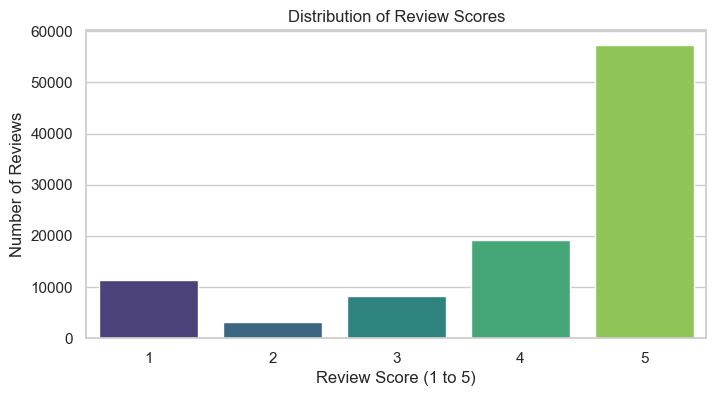


3. RETENTION METRICS:
Total Unique Customers: 95560
Repeat Customers: 2924
Repeat Purchase Rate: 3.06%
Average time between orders: 78.9 days (Median: 29.0 days)

4. TOP CATEGORIES:

Top 5 by Orders:
product_category_name_english  total_orders  total_gmv
               bed_bath_table          9417 1241681.72
                health_beauty          8836 1441248.07
               sports_leisure          7720 1156656.48
        computers_accessories          6689 1059272.40
              furniture_decor          6449  902511.79

Top 5 by GMV:
product_category_name_english  total_orders  total_gmv
                health_beauty          8836 1441248.07
                watches_gifts          5624 1305541.61
               bed_bath_table          9417 1241681.72
               sports_leisure          7720 1156656.48
        computers_accessories          6689 1059272.40


C:\Users\Siq\AppData\Local\Temp\ipykernel_16848\608648165.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_by_gmv, y='product_category_name_english', x='total_gmv', palette='Greens_r')


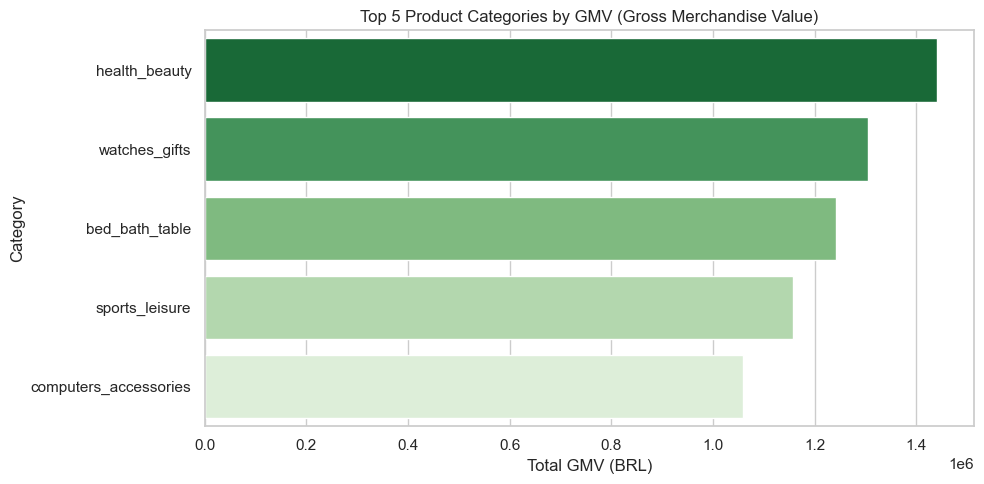

In [23]:
# Conversion view
total_orders_raw = orders.shape[0]
status_distribution = orders['order_status'].value_counts(normalize=True) * 100
delivered_share = status_distribution.get('delivered', 0)

print(f"\n1. CONVERSION VIEW:")
print(f"Total Orders: {total_orders_raw}")
print(f"Delivered Orders Share: {delivered_share:.2f}%")
print(status_distribution.round(2).head(3)) # Top 3 status

# Review score distribution
print(f"\n2. REVIEW SCORE DISTRIBUTION:")
plt.figure(figsize=(8, 4))
sns.countplot(data=reviews, x='review_score', palette='viridis')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score (1 to 5)')
plt.ylabel('Number of Reviews')
plt.show()

#Repeat purchase rate per customer & average time between orders, merge orders with customers to get unique customer ID
orders_customers = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
valid_orders = orders_customers[orders_customers['order_status'] != 'canceled'].copy()

order_counts = valid_orders.groupby('customer_unique_id')['order_id'].nunique()
repeat_customers = (order_counts > 1).sum()
repeat_rate = (repeat_customers / len(order_counts)) * 100

print(f"\n3. RETENTION METRICS:")
print(f"Total Unique Customers: {len(order_counts)}")
print(f"Repeat Customers: {repeat_customers}")
print(f"Repeat Purchase Rate: {repeat_rate:.2f}%")

# Average time between orders for repeat customers
valid_orders = valid_orders.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
valid_orders['next_order_date'] = valid_orders.groupby('customer_unique_id')['order_purchase_timestamp'].shift(-1)
valid_orders['days_to_next_order'] = (valid_orders['next_order_date'] - valid_orders['order_purchase_timestamp']).dt.days

avg_days = valid_orders['days_to_next_order'].dropna().mean()
median_days = valid_orders['days_to_next_order'].dropna().median()
print(f"Average time between orders: {avg_days:.1f} days (Median: {median_days:.1f} days)")

# Top product categories by orders and GMV, Merge items with products and translation
items_prod = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_prod = items_prod.merge(translation, on='product_category_name', how='left')

# GMV = price + freight
items_prod['gmv'] = items_prod['price'] + items_prod['freight_value']

category_stats = items_prod.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'nunique'),
    total_gmv=('gmv', 'sum')
).reset_index()

top_by_orders = category_stats.sort_values('total_orders', ascending=False).head(5)
top_by_gmv = category_stats.sort_values('total_gmv', ascending=False).head(5)

print(f"\n4. TOP CATEGORIES:")
print("\nTop 5 by Orders:")
print(top_by_orders.to_string(index=False))
print("\nTop 5 by GMV:")
print(top_by_gmv.to_string(index=False))

# Plot Top Categories by GMV
plt.figure(figsize=(10, 5))
sns.barplot(data=top_by_gmv, y='product_category_name_english', x='total_gmv', palette='Greens_r')
plt.title('Top 5 Product Categories by GMV (Gross Merchandise Value)')
plt.xlabel('Total GMV (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## Part 2 — Modeling

In [24]:
def build_analytical_base_table_final(orders_df, items_df, customers_df, sellers_df, products_df, translation_df, reviews_df, payments_df):
    

# Orders may include multiple payment records (two credit cards), select the first payment to simplify the baseline implementation.
    pay_agg = payments_df.groupby('order_id')['payment_type'].first().reset_index()
    
    #BASIC MERGES
    df_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()
    df_orders = df_orders.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])
    df_orders['is_on_time'] = (df_orders['order_delivered_customer_date'] <= df_orders['order_estimated_delivery_date']).astype(int)
    
    # Features date
    df_orders['estimated_delivery_days'] = (df_orders['order_estimated_delivery_date'] - df_orders['order_purchase_timestamp']).dt.days
    df_orders['purchase_month'] = df_orders['order_purchase_timestamp'].dt.month
    df_orders['purchase_day_of_week'] = df_orders['order_purchase_timestamp'].dt.dayofweek
    
    # aggregated items
    items_agg = items_df.groupby('order_id').agg(
        total_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        total_items=('order_item_id', 'count'),
        seller_id=('seller_id', 'first'),
        product_id=('product_id', 'first')
    ).reset_index()
    
    abt = df_orders.merge(items_agg, on='order_id', how='left')
    
    # Merge Customers & Sellers
    abt = abt.merge(customers_df[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id', how='left')
    abt = abt.merge(sellers_df[['seller_id', 'seller_state']], on='seller_id', how='left')
    
    # distance feature
    abt['is_same_state'] = (abt['customer_state'] == abt['seller_state']).astype(int)
    
    # MERGE PAYMENTS
    abt = abt.merge(pay_agg, on='order_id', how='left')
    abt['payment_type'] = abt['payment_type'].fillna('unknown')
    
    # MERGE PRODUCTS
    products_en = products_df.merge(translation_df, on='product_category_name', how='left')
    abt = abt.merge(products_en[['product_id', 'product_category_name_english', 'product_weight_g']], on='product_id', how='left')
    
    abt['product_category_name_english'] = abt['product_category_name_english'].fillna('unknown')
    abt['product_weight_g'] = abt['product_weight_g'].fillna(abt['product_weight_g'].median())
    
    print(f"Final shape: {abt.shape}")
    return abt

# Master DF
df_master = build_analytical_base_table_final(orders, items, customers, sellers, products, translation, reviews, payments)

# Display a quick summary of our target variable
print("\nTarget Variable Distribution (is_on_time):")
print(df_master['is_on_time'].value_counts(normalize=True).round(4) * 100)

Final shape: (96470, 24)

Target Variable Distribution (is_on_time):
is_on_time
1    91.89
0     8.11
Name: proportion, dtype: float64


In [25]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  object        
 1   customer_id                    96470 non-null  object        
 2   order_status                   96470 non-null  object        
 3   order_purchase_timestamp       96470 non-null  datetime64[ns]
 4   order_approved_at              96456 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96469 non-null  datetime64[ns]
 6   order_delivered_customer_date  96470 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96470 non-null  datetime64[ns]
 8   is_on_time                     96470 non-null  int64         
 9   estimated_delivery_days        96470 non-null  int64         
 10  purchase_month                 96470 non-null  int32         
 11  purchase_day_of

In [26]:

# DATA PREP, DISTRIBUTION CHECK & FEATURE SELECTION

#Valid Features
numeric_features =['estimated_delivery_days', 'total_price', 'total_freight', 'total_items', 'product_weight_g']
categorical_features =['purchase_month', 'purchase_day_of_week', 'is_same_state', 'customer_state', 'seller_state', 'product_category_name_english', 'payment_type']
target = 'is_on_time'

# Ensure data is sorted by purchase date (Temporal Split)
df_master = df_master.sort_values('order_purchase_timestamp')

X = df_master[numeric_features + categorical_features]
y = df_master[target]

#Temporal Split with 80% Train and 20% Test
split_index = int(len(df_master) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training Set: {X_train.shape[0]} records")
print(f"Testing Set:  {X_test.shape[0]} records")

# DISTRIBUTION CHECK
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100
print(f"Train - On Time: {train_dist[1]:.2f}% | Late: {train_dist[0]:.2f}%")
print(f"Test  - On Time: {test_dist[1]:.2f}% | Late: {test_dist[0]:.2f}%")

#Baseline Model
y_pred_baseline = [1] * len(y_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"ROC-AUC:  0.5000")

#Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

#Feature Selection
feature_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    threshold="median"
)

#Extract Importances
X_train_transformed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

feature_selector.fit(X_train_transformed, y_train)
selected_mask = feature_selector.get_support()
importances = feature_selector.estimator_.feature_importances_

# 7. Visualize Selected Features
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Selected': selected_mask
}).sort_values(by='Importance', ascending=False)

print(f"\nTotal features after OneHotEncoding: {len(feature_names)}")
print(f"Total features kept by the selector: {selected_mask.sum()}")
print("\n--- TOP 10 SELECTED FEATURES ---")
print(feature_importance_df[feature_importance_df['Selected']].head(10).to_string(index=False))

Training Set: 77176 records
Testing Set:  19294 records
Train - On Time: 91.18% | Late: 8.82%
Test  - On Time: 94.71% | Late: 5.29%
Accuracy: 0.9471
ROC-AUC:  0.5000

Total features after OneHotEncoding: 152
Total features kept by the selector: 76

--- TOP 10 SELECTED FEATURES ---
                      Feature  Importance  Selected
             num__total_price    0.128785      True
           num__total_freight    0.123278      True
        num__product_weight_g    0.119443      True
 num__estimated_delivery_days    0.104757      True
        cat__purchase_month_3    0.016233      True
  cat__purchase_day_of_week_1    0.016008      True
  cat__purchase_day_of_week_2    0.015376      True
  cat__purchase_day_of_week_0    0.015207      True
cat__payment_type_credit_card    0.015155      True
  cat__purchase_day_of_week_3    0.014966      True



Training Random Forest (Baseline)
--- Random Forest (Baseline) PERFORMANCE ---
METRIC          | TRAIN      | TEST       | DELTA
--------------------------------------------------
Accuracy        | 0.7893     | 0.9445     | -0.1552
ROC-AUC         | 0.8387     | 0.5416     | 0.2971
PR-AUC (Late)   | 0.3611     | 0.0608     | 0.3003
F1-Macro        | 0.6214     | 0.4904     | 0.1311

Classification Report (TEST SET):
              precision    recall  f1-score   support

           0       0.08      0.00      0.01      1021
           1       0.95      1.00      0.97     18273

    accuracy                           0.94     19294
   macro avg       0.52      0.50      0.49     19294
weighted avg       0.90      0.94      0.92     19294



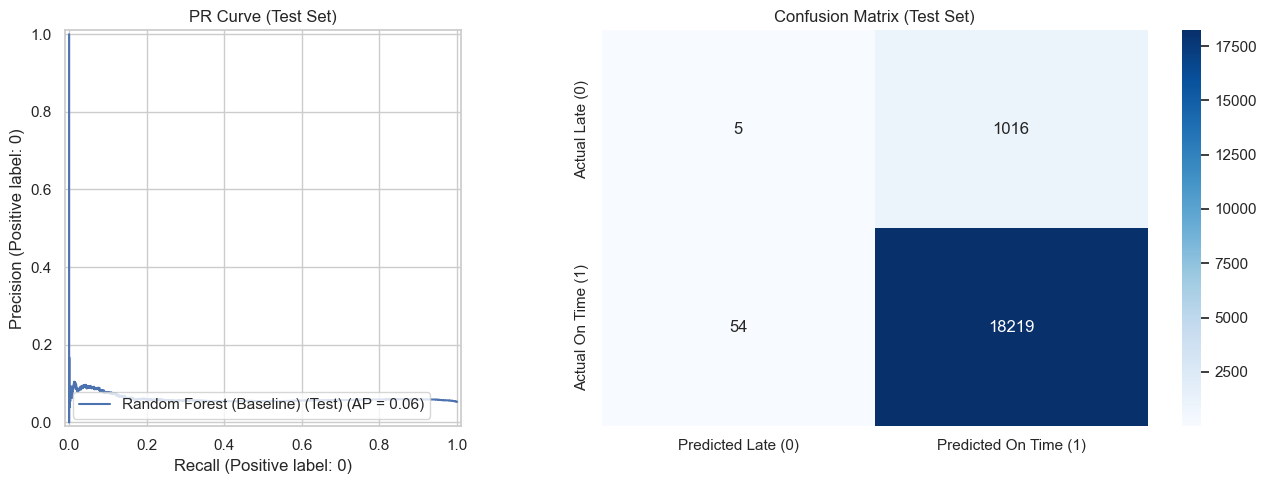


Training LightGBM with GridSearchCV 
Fitting 3 folds for each of 8 candidates, totalling 24 fits


c:\Users\Siq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Siq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Siq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Siq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- LightGBM with GridSearchCV  PERFORMANCE ---
Best Parameters Found: {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 200, 'classifier__num_leaves': 31}
METRIC          | TRAIN      | TEST       | DELTA
--------------------------------------------------
Accuracy        | 0.7593     | 0.8758     | -0.1166
ROC-AUC         | 0.8332     | 0.6810     | 0.1523
PR-AUC (Late)   | 0.3456     | 0.0940     | 0.2516
F1-Macro        | 0.6016     | 0.5278     | 0.0738

Classification Report (TEST SET):
              precision    recall  f1-score   support

           0       0.10      0.16      0.12      1021
           1       0.95      0.92      0.93     18273

    accuracy                           0.88     19294
   macro avg       0.52      0.54      0.53     19294
weighted avg       0.91      0.88      0.89     19294



c:\Users\Siq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


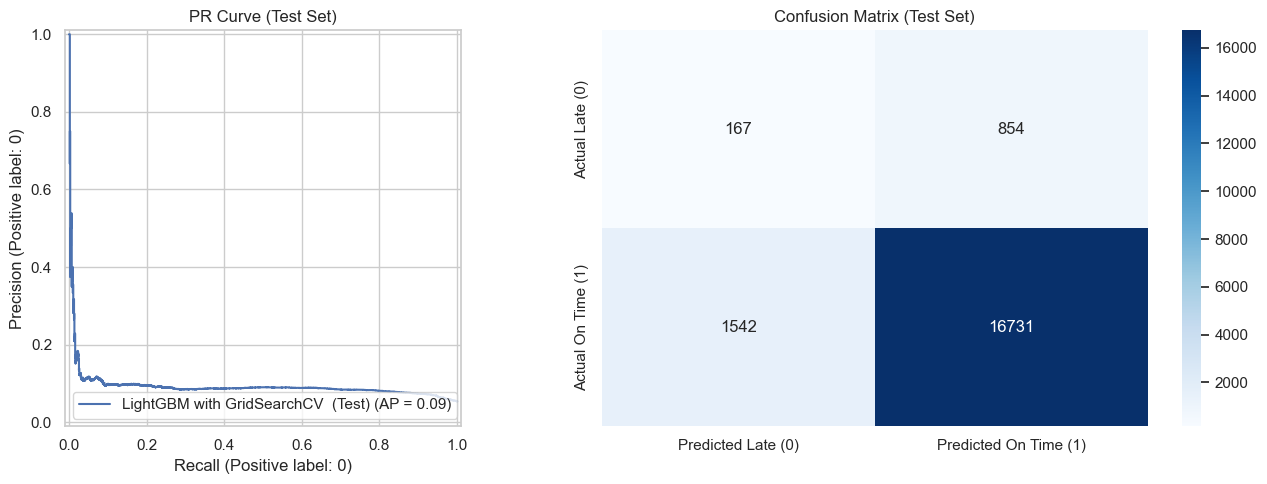

In [28]:
#Define Models
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('selector', feature_selector), ('classifier', rf_model)])
pipeline_lgbm_base = Pipeline(steps=[('preprocessor', preprocessor), ('selector', feature_selector), ('classifier', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1))])

# Hyperparameter Tuning
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__num_leaves': [31, 40]
}
time_series_cv = TimeSeriesSplit(n_splits=3)
grid_search_ts = GridSearchCV(pipeline_lgbm_base, param_grid, cv=time_series_cv, scoring='roc_auc', n_jobs=-1, verbose=1)

#Train and Evaluate Function
def train_and_evaluate(pipeline, name, X_train, y_train, X_test, y_test):
    print(f"\nTraining {name}")
    pipeline.fit(X_train, y_train)
    
    #PREDICTIONS 
    # Test Set
    y_pred_test = pipeline.predict(X_test)
    y_prob_test = pipeline.predict_proba(X_test)
    y_prob_test_class_0 = y_prob_test[:, 0] # Prob of Late(here is the oposite for 0 and 1)
    
    # Train Set for Overfitting Check
    y_pred_train = pipeline.predict(X_train)
    y_prob_train = pipeline.predict_proba(X_train)
    y_prob_train_class_0 = y_prob_train[:, 0]
    
    #METRICS CALCULATION
    def get_metrics(y_true, y_pred, y_prob_c1, y_prob_c0):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "roc": roc_auc_score(y_true, y_prob_c1),
            "pr_auc": average_precision_score(1 - y_true, y_prob_c0), # Class 0 target
            "f1": f1_score(y_true, y_pred, average='macro')
        }

    test_metrics = get_metrics(y_test, y_pred_test, y_prob_test[:, 1], y_prob_test_class_0)
    train_metrics = get_metrics(y_train, y_pred_train, y_prob_train[:, 1], y_prob_train_class_0)
    
    print(f"--- {name} PERFORMANCE ---")
    if isinstance(pipeline, GridSearchCV):
        print(f"Best Parameters Found: {pipeline.best_params_}")
    
    # compare
    print(f"{'METRIC':<15} | {'TRAIN':<10} | {'TEST':<10} | {'DELTA'}")
    print("-" * 50)
    print(f"{'Accuracy':<15} | {train_metrics['acc']:.4f}     | {test_metrics['acc']:.4f}     | {train_metrics['acc'] - test_metrics['acc']:.4f}")
    print(f"{'ROC-AUC':<15} | {train_metrics['roc']:.4f}     | {test_metrics['roc']:.4f}     | {train_metrics['roc'] - test_metrics['roc']:.4f}")
    print(f"{'PR-AUC (Late)':<15} | {train_metrics['pr_auc']:.4f}     | {test_metrics['pr_auc']:.4f}     | {train_metrics['pr_auc'] - test_metrics['pr_auc']:.4f}")
    print(f"{'F1-Macro':<15} | {train_metrics['f1']:.4f}     | {test_metrics['f1']:.4f}     | {train_metrics['f1'] - test_metrics['f1']:.4f}")
    
    print("\nClassification Report (TEST SET):")
    print(classification_report(y_test, y_pred_test))
    
    # plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    #PR Curve
    PrecisionRecallDisplay.from_estimator(pipeline, X_test, y_test, name=f"{name} (Test)", pos_label=0, ax=axes[0])
    axes[0].set_title(f"PR Curve (Test Set)")
    
    # 2. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
                xticklabels=['Predicted Late (0)', 'Predicted On Time (1)'],
                yticklabels=['Actual Late (0)', 'Actual On Time (1)'])
    axes[1].set_title(f"Confusion Matrix (Test Set)")
    
    plt.tight_layout()
    plt.show()
    
    return pipeline

# Run Models
trained_rf_ts = train_and_evaluate(pipeline_rf, "Random Forest (Baseline)", X_train, y_train, X_test, y_test)
tuned_lgbm_ts = train_and_evaluate(grid_search_ts, "LightGBM with GridSearchCV ", X_train, y_train, X_test, y_test)

1. Ensuring model variable exists by re-running training...

Training LightGBM (Final Save)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


c:\Users\Siq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Siq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Siq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Siq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- LightGBM (Final Save) PERFORMANCE ---
Best Parameters Found: {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 200, 'classifier__num_leaves': 40}
METRIC          | TRAIN      | TEST       | DELTA
--------------------------------------------------
Accuracy        | 0.7690     | 0.8778     | -0.1088
ROC-AUC         | 0.8490     | 0.6766     | 0.1724
PR-AUC (Late)   | 0.3675     | 0.0897     | 0.2778
F1-Macro        | 0.6122     | 0.5272     | 0.0850

Classification Report (TEST SET):
              precision    recall  f1-score   support

           0       0.10      0.16      0.12      1021
           1       0.95      0.92      0.93     18273

    accuracy                           0.88     19294
   macro avg       0.52      0.54      0.53     19294
weighted avg       0.91      0.88      0.89     19294



c:\Users\Siq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


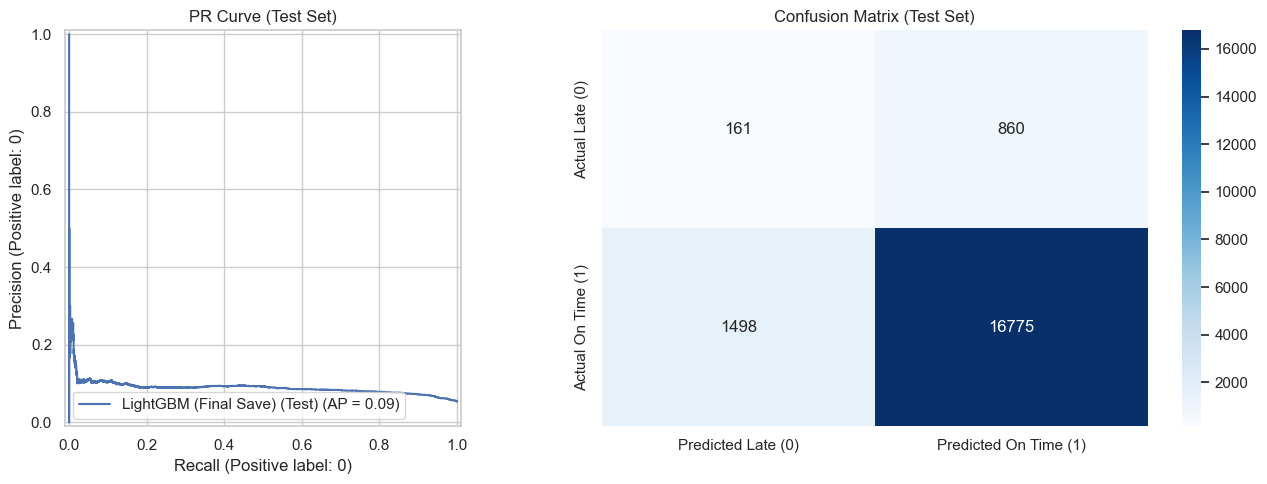

2. Training complete. Saving model...
✅ SUCCESS! Model saved to: c:\Users\Siq\Desktop\Gerald Challange\artifacts\on_time_delivery_model.pkl
   You can now run the CLI using: python -m src.main --customer_id <SOME_ID>


In [ ]:
ARTIFACTS_DIR = 'artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
MODEL_PATH = os.path.join(ARTIFACTS_DIR, "on_time_delivery_model.pkl")
# 2. Re-run only the winning model training
try:
    tuned_lgbm_ts = train_and_evaluate(grid_search_ts, "LightGBM (Final Save)", X_train, y_train, X_test, y_test)
    
    print("2. Training complete. Saving model...")
    
    #Save the model object with the best parameters
    joblib.dump(tuned_lgbm_ts.best_estimator_, MODEL_PATH, compress=3)
    
    print(f" Model saved to: {os.path.abspath(MODEL_PATH)}")

except NameError as e:
    print(f" ERROR: Missing dependency. Make sure you ran the Data Prep and GridSearch definition cells above. Details: {e}")
except Exception as e:
    print(f" ERROR: Could not save model. Details: {e}")